In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

In [4]:
scaled_df = pd.read_csv("../data/Master_data/scaled_data.csv")

In [5]:

print(scaled_df.shape)
print(scaled_df.columns)
scaled_df.head()


(482117, 69)
Index(['month', 'year', 'noOfRcs', 'noOfTrans', 'riceAfsc', 'riceFsc',
       'riceAap', 'wheat', 'sugar', 'totalAmount', 'otherShopTransCnt',
       'riceAap_available', 'wheat_available', 'totalRcs', 'totalUnits',
       'units', 'longitude', 'latitude', 'fpsStatus', 'fpsType', 'week',
       'quarter', 'is_weekend', 'day_of_year', 'month_start', 'month_end',
       'days_in_month', 'utilization_ratio', 'units_per_card',
       'amount_per_transaction', 'amount_per_card', 'rice_afsc_per_trans',
       'rice_fsc_per_trans', 'rice_aap_per_trans', 'wheat_per_trans',
       'rice_to_wheat_ratio', 'sugar_intensity', 'wheat_intensity',
       'rice_share', 'commodity_activity', 'other_shop_ratio',
       'portability_hub_score', 'portability_intensity', 'high_non_local_flag',
       'trans_per_card_FRAUD_DETECTION', 'units_per_trans_FRAUD_DETECTION',
       'fraud_risk_flag', 'post_onorc', 'urban_proxy', 'distribution_change',
       'transaction_volatility', 'amount_volatilit

,month,year,noOfRcs,noOfTrans,riceAfsc,riceFsc,riceAap,wheat,sugar,totalAmount,...,peak_month_flag,festival_quarter,high_performance_shop,low_activity_shop,high_revenue_shop,availability_score,active_fps,missing_geo_flag,rice_wheat_ratio,distName_freq
0,-1.385245,-1.017165,-0.713706,-0.718301,0.048610,-0.458836,-0.271319,-0.285129,-0.34789,-0.381175,...,0,1,0,0,0,-0.402903,1,0,0.285560,-0.419771
1,-1.093639,-1.017165,-0.593218,-0.590942,0.141764,-0.372330,-0.271319,-0.285129,-0.34789,-0.381175,...,0,1,0,0,0,-0.402903,1,0,0.318854,-0.419771
2,-0.802034,-1.017165,-0.684496,-0.689076,0.081113,-0.402973,-0.271319,-0.285129,-0.34789,-0.381175,...,0,1,0,0,0,-0.402903,1,0,0.297176,-0.419771
3,-0.510428,-1.017165,-0.677279,-0.660393,0.081113,-0.172304,-0.271319,-0.285129,-0.34789,-0.381175,...,0,1,0,0,0,-0.402903,1,0,0.297176,-0.419771
4,-0.218822,-1.017165,-0.593218,-0.590942,0.081113,-0.082694,-0.271319,-0.285129,-0.34789,-0.381175,...,0,1,0,0,0,-0.402903,1,0,0.297176,-0.419771


In [6]:
print(scaled_df.dtypes)

month                 float64
year                  float64
noOfRcs               float64
noOfTrans             float64
riceAfsc              float64
                       ...   
availability_score    float64
active_fps              int64
missing_geo_flag        int64
rice_wheat_ratio      float64
distName_freq         float64
Length: 69, dtype: object


In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(scaled_df)

print(X_pca.shape)

(482117, 20)


In [8]:
print(pca.explained_variance_ratio_)

[0.29816571 0.13868579 0.06840468 0.06116851 0.05938546 0.05040388
 0.04567988 0.03471637 0.02958717 0.02561912 0.02339126 0.02008225
 0.0182688  0.01689824 0.0146192  0.01258854 0.01039547 0.00952365
 0.00889978 0.00856608]


In [9]:
print(sum(pca.explained_variance_ratio_))

0.9550498582089106


In [10]:
import pandas as pd

pca_df = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
)

pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,-1.883081,-1.657850,-0.667426,1.209770,0.200160,2.423177,-0.408070,1.842130,-0.064219,-1.235183,-0.725038,0.633411,-0.104262,0.141564,-0.078688,-1.823807,0.171661,0.120181,-0.434843,0.608808
1,-1.702748,-1.162848,-0.535037,0.912080,0.191925,2.243356,-0.311496,1.799101,-0.384809,-1.970940,-1.551623,0.661592,-0.067265,0.826014,0.095430,-0.916863,-0.088872,-0.017309,-0.314918,0.552199
2,-1.760839,-1.416728,-0.670481,1.113658,0.315450,2.469945,-0.404734,1.880043,0.106647,-1.410823,-0.952711,0.603540,-0.090999,0.555400,0.038820,-1.117344,-0.045478,0.060567,-0.415035,0.593131
3,-1.679315,-1.080482,-0.407049,0.979341,0.080585,3.400451,-0.688134,2.161099,1.201225,-0.131007,0.165717,0.642001,-0.426776,-0.580913,0.040932,-1.596849,0.401356,0.311155,-0.665942,0.726685
4,-1.393210,-0.584055,-0.466927,0.782557,0.395367,3.443759,-0.703478,2.156865,0.847525,-0.678964,-0.560232,0.592566,-0.425019,0.225213,0.220911,-0.645237,0.135157,0.280699,-0.668913,0.715447


In [11]:
print("Before PCA:", scaled_df.shape)
print("After PCA:", pca_df.shape)

Before PCA: (482117, 69)
After PCA: (482117, 20)


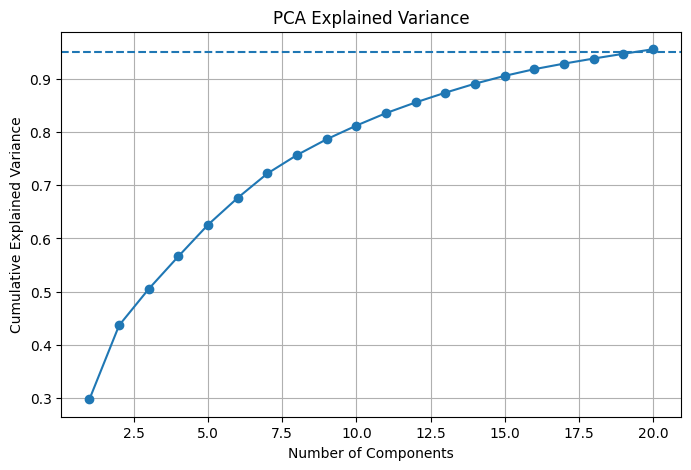

In [12]:
import numpy as np
import matplotlib.pyplot as plt

cum_var = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(cum_var)+1),
    cum_var,
    marker='o'
)

plt.axhline(
    y=0.95,
    linestyle='--'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)

plt.show()

In [14]:
pca_df.to_csv("../data/Master_data/pca_data.csv", index=False)

In [15]:
import joblib

joblib.dump(pca, "../model/pca_model.pkl")

['../model/pca_model.pkl']